# IRT Item Calibration (Author Items)

Input paths follow `scripts/config.json` → `SAMPLE_VERSION` (default **`strict_fa`**, ~**688** participants in the current article pipeline):

- **`full`** → `data/stepwise_cleaned_versions/05_dimensionality_inputs/`; outputs go to `data/stepwise_cleaned_versions/06_irt_item_calibration/`.
- **Tagged versions (e.g. `strict_fa`)** → `data/stepwise_cleaned_versions_<tag>/05_dimensionality_inputs/` **if present**, otherwise `.../03_dimensionality_inputs/`; outputs go to `.../04_irt_item_calibration/`.

Files (same names in the chosen input folder):
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv` — binary 0/1 matrix (N × 98 author items)
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv` — item metadata (labels, genres, endorsement rates, cITC, CFA/EFA loadings, flags from step 05)

Goals:
1. Fit 1PL (Rasch), 2PL, and 3PL IRT models to all 98 author items using `mirt`
2. Compare models via log-likelihood, AIC, BIC, and likelihood-ratio tests; select best-fitting model
3. Extract item parameters (discrimination _a_, difficulty _b_) and person ability estimates (theta)
4. Plot item characteristic curves (ICCs), test information function (TIF), and conditional standard error (CSE)
5. Export enriched item database with IRT-derived flags for downstream item selection

**Note:** The purpose of this notebook is to assign IRT metric flags to each item so that researchers
can later adjust the Russian ART composition for different populations (e.g., higher education vs.
general participants). This is **not** a final item-selection step.

References:

**Note on "Summary" markdown cells:** Some numeric examples (e.g. model comparison χ², item counts) may reflect a previous full-*N* run. For your active `SAMPLE_VERSION`, treat **printed R output** and exported tables as authoritative.

- Moore & Gordon (2015): compared 1PL, 2PL, 3PL; favored 2PL by likelihood-ratio comparison; used item parameters for test improvement
- McCarron & Kuperman (2022): compared one- through three-parameter models; favored 2PL; used discrimination and difficulty to evaluate ART items across cohorts


In [1]:
library(mirt)
library(psych)
library(ggplot2)
library(reshape2)
library(jsonlite)

mc.cores <- 1
Sys.setenv(MC_CORES = 1)

cat(sprintf("R version: %s.%s \n", R.version$major, R.version$minor))
cat(sprintf("mc.cores: %d (forced serial for IRkernel compatibility)\n", mc.cores))
cat("Package versions:\n")
for (pkg in c("mirt", "psych", "ggplot2", "reshape2", "jsonlite")) {
  cat(sprintf("  %-12s %s\n", pkg, as.character(packageVersion(pkg))))
}

Loading required package: stats4

Loading required package: lattice


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha




R version: 4.5.3 
mc.cores: 1 (forced serial for IRkernel compatibility)
Package versions:
  mirt         1.46.1
  psych        2.6.3
  ggplot2      4.0.2
  reshape2     1.4.5
  jsonlite     2.0.0


In [2]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)

config <- fromJSON(file.path(PROJECT_ROOT, "scripts", "config.json"))
SAMPLE_VERSION <- config$SAMPLE_VERSION
RESULTS_TAG <- if (SAMPLE_VERSION == "full") "" else paste0("_", SAMPLE_VERSION)

if (SAMPLE_VERSION == "full") {
  DATA_DIR   <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "05_dimensionality_inputs")
  OUTPUT_DIR <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "06_irt_item_calibration")
} else {
  sample_root <- file.path(PROJECT_ROOT, "data",
                          paste0("stepwise_cleaned_versions_", SAMPLE_VERSION))
  p05 <- file.path(sample_root, "05_dimensionality_inputs")
  p03 <- file.path(sample_root, "03_dimensionality_inputs")
  DATA_DIR   <- if (dir.exists(p05)) p05 else p03
  OUTPUT_DIR <- file.path(sample_root, "04_irt_item_calibration")
}
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

cat("SAMPLE_VERSION:", SAMPLE_VERSION, "\n")
cat("Data dir:       ", DATA_DIR, "\n")
cat("IRT output dir: ", OUTPUT_DIR, "\n")

manifest <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__manifest.csv"),
  stringsAsFactors = FALSE)
cat("── Manifest ──\n")
print(manifest)

author_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv"),
  stringsAsFactors = FALSE)
item_key <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv"),
  stringsAsFactors = FALSE)

author_mat <- as.matrix(author_df[, -which(names(author_df) == "participant_id")])

expected_n <- as.integer(manifest$value[manifest$field == "n_participants"])
expected_k <- as.integer(manifest$value[manifest$field == "n_author_items"])
stopifnot(nrow(author_mat) == expected_n)
stopifnot(ncol(author_mat) == expected_k)
cat(sprintf("\nSanity check passed: n=%d, k=%d match manifest.\n", expected_n, expected_k))

cat("\u2500\u2500 Data loaded \u2500\u2500\n")
cat(sprintf("Response matrix : %d participants \u00d7 %d items\n",
            nrow(author_mat), ncol(author_mat)))
cat(sprintf("Item key        : %d items \u00d7 %d columns\n",
            nrow(item_key), ncol(item_key)))
cat(sprintf("All values 0/1  : %s\n",
            all(author_mat %in% c(0, 1, NA))))

col_vars <- apply(author_mat, 2, var, na.rm = TRUE)
constant_cols <- names(col_vars[col_vars == 0])
if (length(constant_cols) > 0) {
  cat(sprintf("WARNING: %d constant columns detected: %s\n",
              length(constant_cols), paste(constant_cols, collapse = ", ")))
} else {
  cat("No constant columns \u2014 all items have variance.\n")
}

SAMPLE_VERSION: strict_fa 
Data dir:        /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/03_dimensionality_inputs 
IRT output dir:  /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/04_irt_item_calibration 
── Manifest ──
                  field
1      source_data_path
2        n_participants
3        n_author_items
4          n_foil_items
5 author_item_id_scheme
6   foil_item_id_scheme
7 author_item_exclusion
8  foil_item_exclusions
9                  note
                                                                                                                                                                                                                                                   value
1 /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normali

## 5. IRT Model Fitting: 1PL / 2PL / 3PL

### 5.1 Rationale

ART items differ in both **difficulty** (some authors are widely known, others only to heavy readers)
and **discrimination** (some names separate strong and weak readers well, others do not).
This makes the 2PL model the expected best default for ART data.

Both anchor papers compared alternative IRT models and favored 2PL:
- Moore & Gordon (2015) explicitly report that the 2PL fit better than 1PL and 3PL
- McCarron & Kuperman (2022) report that the 2PL fit better than one-parameter and three-parameter alternatives by likelihood-ratio comparison

We fit all three models below and formally compare them.

### 5.2 Implementation

Using `mirt`:
- **1PL (Rasch)**: constrained equal discrimination
- **2PL**: free discrimination and difficulty
- **3PL**: adds a lower-asymptote (guessing) parameter; requires large N and may not converge well

### 5.3 Statistics to report

For each fitted model:
- Log-likelihood
- AIC, BIC
- Likelihood-ratio comparisons (nested models)
- M2 global fit statistic (if available)
- Convergence status

In [3]:
cat("Fitting 1PL (Rasch) model ...\n")
mod_1pl <- mirt(author_mat, model = 1, itemtype = "Rasch",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_1pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_1pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_1pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_1pl, "BIC")))

Fitting 1PL (Rasch) model ...
  Converged : TRUE
  Log-lik   : -27906.10
  AIC       : 56010.20
  BIC       : 56459.05


In [4]:
cat("Fitting 2PL model ...\n")
mod_2pl <- mirt(author_mat, model = 1, itemtype = "2PL",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_2pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_2pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_2pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_2pl, "BIC")))

Fitting 2PL model ...
  Converged : TRUE
  Log-lik   : -27062.92
  AIC       : 54517.85
  BIC       : 55406.47


In [5]:
cat("Fitting 3PL model ...\n")
cat(sprintf("(Note: 3PL adds a guessing parameter; may not converge well with N=%d.)\n\n", nrow(author_mat)))
mod_3pl <- mirt(author_mat, model = 1, itemtype = "3PL",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_3pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_3pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_3pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_3pl, "BIC")))

Fitting 3PL model ...
(Note: 3PL adds a guessing parameter; may not converge well with N=688.)



Warning message:
“Could not invert information matrix; model may not be (empirically) identified.”


  Converged : TRUE
  Log-lik   : -26984.31
  AIC       : 54556.61
  BIC       : 55889.55


In [6]:
cat("\u2500\u2500 Model comparison table \u2500\u2500\n\n")

comp_df <- data.frame(
  Model      = c("1PL (Rasch)", "2PL", "3PL"),
  Converged  = c(mod_1pl@OptimInfo$converged,
                 mod_2pl@OptimInfo$converged,
                 mod_3pl@OptimInfo$converged),
  LogLik     = c(extract.mirt(mod_1pl, "logLik"),
                 extract.mirt(mod_2pl, "logLik"),
                 extract.mirt(mod_3pl, "logLik")),
  AIC        = c(extract.mirt(mod_1pl, "AIC"),
                 extract.mirt(mod_2pl, "AIC"),
                 extract.mirt(mod_3pl, "AIC")),
  BIC        = c(extract.mirt(mod_1pl, "BIC"),
                 extract.mirt(mod_2pl, "BIC"),
                 extract.mirt(mod_3pl, "BIC")),
  stringsAsFactors = FALSE
)
print(comp_df, row.names = FALSE)

cat("\n\u2500\u2500 Likelihood-ratio tests \u2500\u2500\n\n")
cat("--- 1PL vs 2PL ---\n")
print(anova(mod_1pl, mod_2pl))

cat("\n--- 2PL vs 3PL ---\n")
print(anova(mod_2pl, mod_3pl))

cat("\n\u2500\u2500 M2 global fit (2PL) \u2500\u2500\n")
m2_2pl <- tryCatch(M2(mod_2pl), error = function(e) {
  cat(sprintf("M2 not available: %s\n", e$message)); NULL
})
if (!is.null(m2_2pl)) print(m2_2pl)

── Model comparison table ──

       Model Converged    LogLik      AIC      BIC
 1PL (Rasch)      TRUE -27906.10 56010.20 56459.05
         2PL      TRUE -27062.92 54517.85 55406.47
         3PL      TRUE -26984.31 54556.61 55889.55

── Likelihood-ratio tests ──

--- 1PL vs 2PL ---
             AIC    SABIC       HQ      BIC    logLik       X2 df p
mod_1pl 56010.20 56144.71 56183.85 56459.05 -27906.10              
mod_2pl 54517.85 54784.14 54861.63 55406.47 -27062.92 1686.354 97 0

--- 2PL vs 3PL ---
             AIC    SABIC       HQ      BIC    logLik      X2 df p
mod_2pl 54517.85 54784.14 54861.63 55406.47 -27062.92             
mod_3pl 54556.61 54956.05 55072.28 55889.55 -26984.31 157.235 98 0

── M2 global fit (2PL) ──
            M2   df p RMSEA RMSEA_5 RMSEA_95 SRMSR   TLI   CFI
stats 17575.53 4655 0 0.064   0.063    0.065 0.059 0.935 0.936


## 6. Interpreting 2PL Item Parameters

### 6.1 Item difficulty (_b_)

- **Low _b_**: easy item — even low-print-exposure participants recognize the author
- **High _b_**: difficult item — mainly informative for stronger readers

Both papers interpret author-item difficulty in exactly this way.

### 6.2 Item discrimination (_a_)

- **High _a_**: item sharply distinguishes low vs. high print exposure
- **Low _a_**: item contributes little to separating participants

Moore & Gordon used these estimates directly for item evaluation and test improvement;
McCarron & Kuperman used them to compare the usefulness of ART items across cohorts.

In [7]:
params_2pl <- coef(mod_2pl, IRTpars = TRUE, simplify = TRUE)$items
params_df  <- as.data.frame(params_2pl)
params_df$matrix_item_id <- rownames(params_df)

names(params_df)[names(params_df) == "a"]  <- "irt06_2pl_a"
names(params_df)[names(params_df) == "b"]  <- "irt06_2pl_b"
params_df$g <- NULL
params_df$u <- NULL

id_to_label <- setNames(item_key$item_label, item_key$matrix_item_id)
params_df$item_label <- id_to_label[params_df$matrix_item_id]

cat("\u2500\u2500 2PL item parameters (first 10 rows) \u2500\u2500\n")
print(head(params_df[, c("matrix_item_id", "item_label", "irt06_2pl_a", "irt06_2pl_b")], 10))

── 2PL item parameters (first 10 rows) ──
     matrix_item_id             item_label irt06_2pl_a irt06_2pl_b
A001           A001        Khaled Hosseini    1.098847   1.9205399
A002           A002            Donna Tartt    1.758748   0.7111748
A003           A003       Archibald Cronin    1.533804   1.6674278
A004           A004          Gillian Flynn    1.176553   1.9302795
A005           A005 Gabriel Garsia Marquez    3.416174  -0.9780281
A006           A006  James Fenimore Cooper    1.463605  -0.6423866
A007           A007     Henryk Sienkiewicz    2.049294   0.1505574
A008           A008          Paula Hawkins    0.932019   2.8049966
A009           A009          George Orwell    1.913906  -1.9337598
A010           A010            Jane Austen    1.759902  -1.5317223


── Discrimination (a) summary ──
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1774  1.2327  1.6091  1.7452  2.1895  3.5025 
  SD: 0.729

── Difficulty (b) summary ──
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-9.84852 -0.83408 -0.07634 -0.09219  0.59450  4.39839 
  SD: 1.848


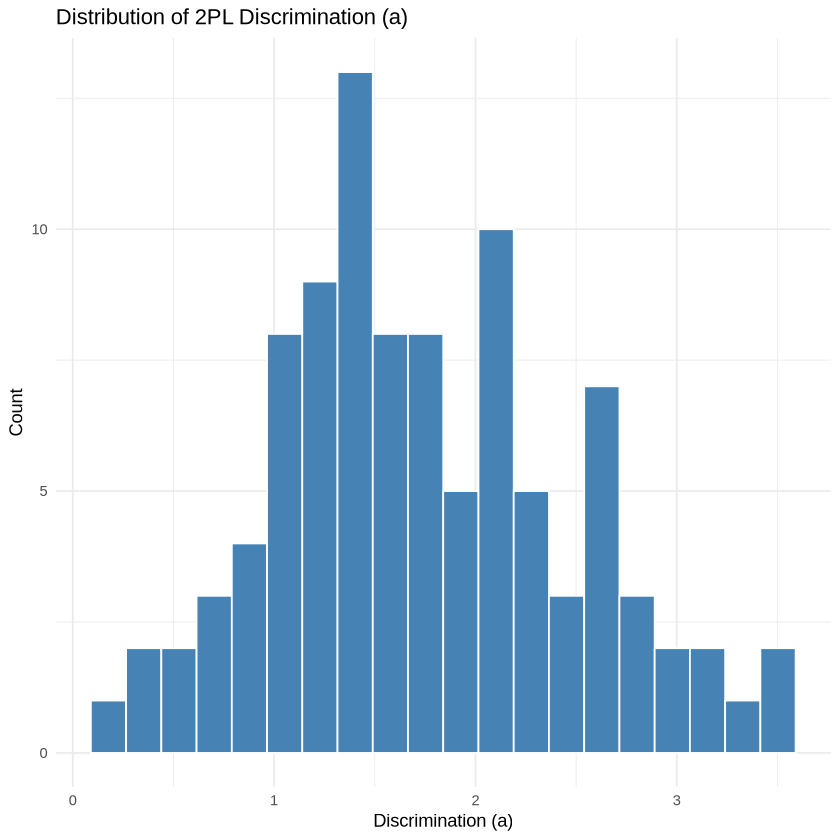


── Extreme-value items ──
  a < 0.5 : 5 items  [George R.R. Martin, Andrzej Sapkovski, Alane Moore, Jules Verne, Andrey Belyanin]
  a > 3.0 : 6 items  [Gabriel Garsia Marquez, Somerset Maugham, Ray Bradbury, Haruki Murakami, Milorad Pavic, Victor Pelevin]
  |b| > 3 : 7 items  [John R.R. Tolkien, Lee Bardugo, Catherine Stokett, Gregory David Roberts, Jules Verne, Reshad Nuri Gyuntekin, Andrey Belyanin]


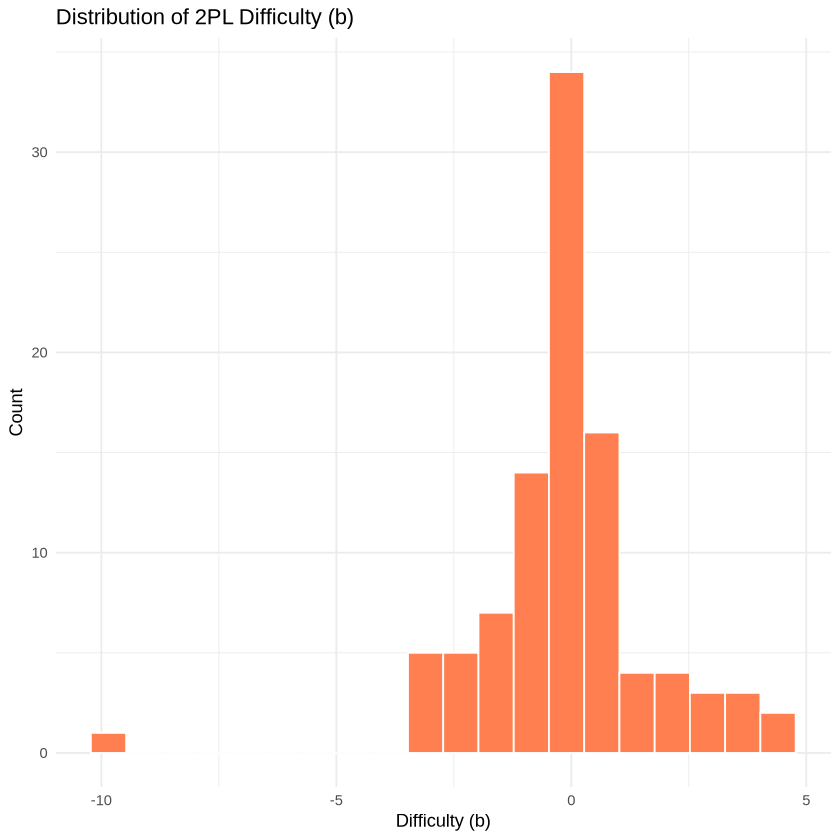

In [8]:
cat("\u2500\u2500 Discrimination (a) summary \u2500\u2500\n")
print(summary(params_df$irt06_2pl_a))
cat(sprintf("  SD: %.3f\n\n", sd(params_df$irt06_2pl_a)))

cat("\u2500\u2500 Difficulty (b) summary \u2500\u2500\n")
print(summary(params_df$irt06_2pl_b))
cat(sprintf("  SD: %.3f\n", sd(params_df$irt06_2pl_b)))

p1 <- ggplot(params_df, aes(x = irt06_2pl_a)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white") +
  labs(title = "Distribution of 2PL Discrimination (a)",
       x = "Discrimination (a)", y = "Count") +
  theme_minimal()

p2 <- ggplot(params_df, aes(x = irt06_2pl_b)) +
  geom_histogram(bins = 20, fill = "coral", color = "white") +
  labs(title = "Distribution of 2PL Difficulty (b)",
       x = "Difficulty (b)", y = "Count") +
  theme_minimal()

print(p1)
print(p2)

cat("\n\u2500\u2500 Extreme-value items \u2500\u2500\n")
low_a  <- params_df$irt06_2pl_a < 0.5
high_a <- params_df$irt06_2pl_a > 3.0
ext_b  <- abs(params_df$irt06_2pl_b) > 3.0
cat(sprintf("  a < 0.5 : %d items  [%s]\n",
            sum(low_a), paste(params_df$item_label[low_a], collapse = ", ")))
cat(sprintf("  a > 3.0 : %d items  [%s]\n",
            sum(high_a), paste(params_df$item_label[high_a], collapse = ", ")))
cat(sprintf("  |b| > 3 : %d items  [%s]\n",
            sum(ext_b), paste(params_df$item_label[ext_b], collapse = ", ")))

In [9]:
prev_irt_cols <- grep("^irt06_|^flag_irt06_", names(item_key), value = TRUE)
if (length(prev_irt_cols) > 0) {
  item_key <- item_key[, !(names(item_key) %in% prev_irt_cols)]
}

item_key <- merge(item_key,
                  params_df[, c("matrix_item_id", "irt06_2pl_a", "irt06_2pl_b")],
                  by = "matrix_item_id", all.x = TRUE)

item_key$flag_irt06_low_discrimination  <- item_key$irt06_2pl_a < 0.5
item_key$flag_irt06_high_discrimination <- item_key$irt06_2pl_a > 2.5
item_key$flag_irt06_extreme_difficulty   <- abs(item_key$irt06_2pl_b) > 3.0

item_key$irt06_keep_drop_review <- ifelse(
  item_key$flag_irt06_low_discrimination | item_key$flag_citc_negative == "True",
  "drop",
  ifelse(
    item_key$flag_irt06_extreme_difficulty |
      item_key$flag_dim05_cfa_loading_below_020 == TRUE |
      item_key$flag_endorsement_extreme_..05_or_..95 == "True",
    "review",
    "keep"
  )
)

item_key$irt06_rationale <- ifelse(
  item_key$irt06_keep_drop_review == "drop",
  ifelse(item_key$flag_irt06_low_discrimination,
         "low discrimination (a < 0.5)",
         "negative corrected item-total correlation"),
  ifelse(
    item_key$irt06_keep_drop_review == "review",
    paste0(
      ifelse(item_key$flag_irt06_extreme_difficulty, "extreme difficulty; ", ""),
      ifelse(item_key$flag_dim05_cfa_loading_below_020 == TRUE, "CFA loading < .20; ", ""),
      ifelse(item_key$flag_endorsement_extreme_..05_or_..95 == "True",
             "extreme endorsement rate; ", "")
    ),
    ""
  )
)
item_key$irt06_rationale <- trimws(gsub(";\\s*$", "", item_key$irt06_rationale))

cat("\u2500\u2500 Keep / Drop / Review tally \u2500\u2500\n")
print(table(item_key$irt06_keep_drop_review))

── Keep / Drop / Review tally ──

  drop   keep review 
     5     80     13 


In [10]:
display_cols <- c("matrix_item_id", "item_label", "genre",
                  "selection_rate_pct", "corrected_item_total_corr",
                  "dim05_cfa_loading_full",
                  "irt06_2pl_a", "irt06_2pl_b",
                  "irt06_keep_drop_review", "irt06_rationale")

decision_tbl <- item_key[, display_cols]
decision_tbl <- decision_tbl[order(decision_tbl$irt06_keep_drop_review,
                                   -decision_tbl$irt06_2pl_a), ]

cat("\u2500\u2500 Item decision table (sorted by decision, then discrimination desc) \u2500\u2500\n\n")
print(decision_tbl, row.names = FALSE, right = FALSE)

── Item decision table (sorted by decision, then discrimination desc) ──

 matrix_item_id item_label              genre              selection_rate_pct
 A085           Jules Verne             Classics           99.1              
 A025           George R.R. Martin      Fantasy            78.1              
 A070           Alane Moore             Sci-Fi             43.5              
 A055           Andrzej Sapkovski       Fantasy            65.3              
 A098           Andrey Belyanin         Modern/Literary    31.5              
 A050           Somerset Maugham        Classics           69.6              
 A005           Gabriel Garsia Marquez  Classics           80.2              
 A078           Victor Pelevin          Modern/Literary    90.6              
 A053           Milorad Pavic           Classics           37.2              
 A052           Haruki Murakami         Modern/Literary    93.5              
 A019           William Thackeray       Classics           54.2     

## 7. ICCs, Information, and Measurement Precision

### 7.1 Item characteristic curves (ICCs)

ICCs show the probability of endorsing each author as a function of latent print exposure (theta).
We plot subsets of items to illustrate the range of difficulty and discrimination:
- **Easiest 10** (lowest _b_)
- **Hardest 10** (highest _b_)
- **Highest-discrimination 10** (highest _a_)
- **Lowest-discrimination 10** (lowest _a_)

Moore & Gordon and McCarron & Kuperman both use ICCs to show what kinds of readers each item is informative for.

### 7.2 Test information function (TIF)

The TIF shows where the Russian ART measures best across the theta continuum.
Moore & Gordon concluded that ART was more informative at the higher end and suggested adding easier items.
McCarron & Kuperman show that some cohorts had poor information and large error at low theta.

### 7.3 Conditional standard error (CSE)

SE(theta) shows measurement precision across the ability range. This is one of the most
useful outputs because it reveals whether the Russian ART is precise for:
- Low-literacy / low-reading participants
- Average readers
- Heavy readers

McCarron & Kuperman's paper strongly supports including this plot.

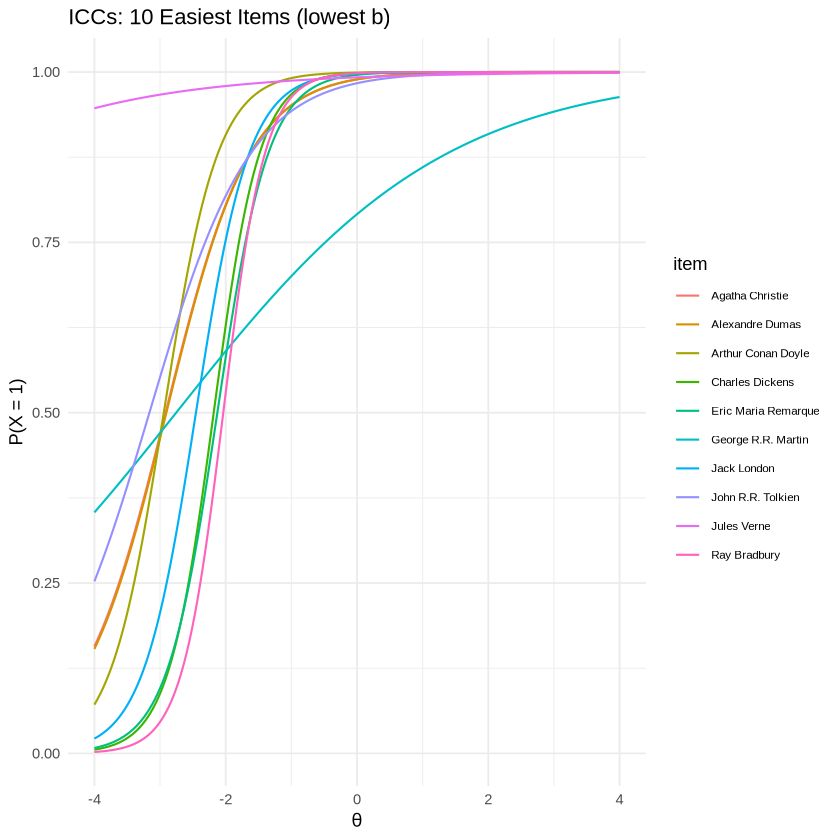

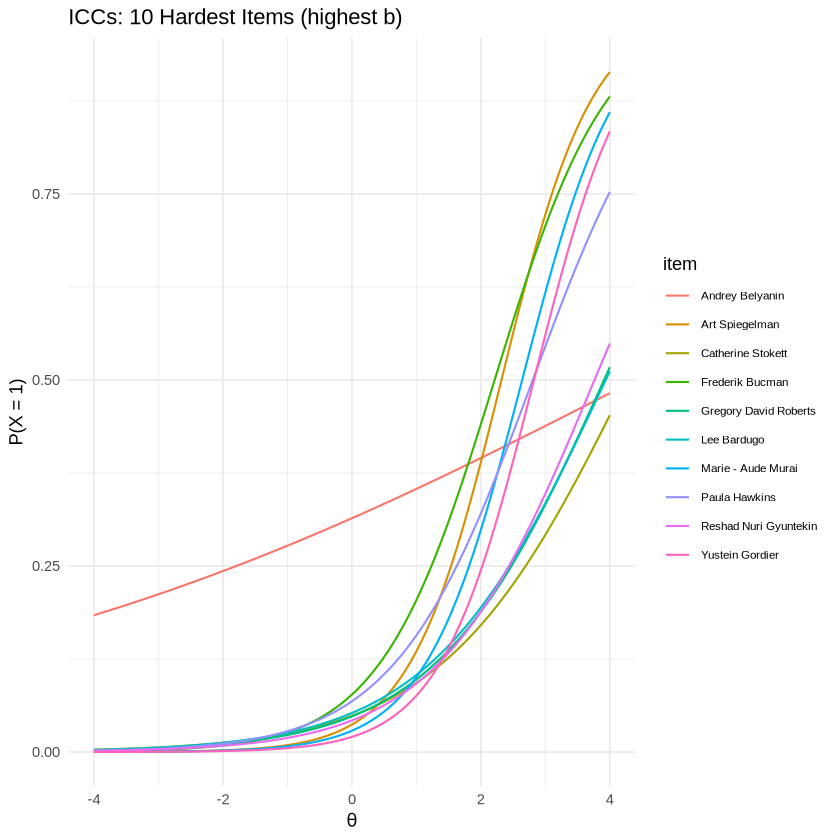

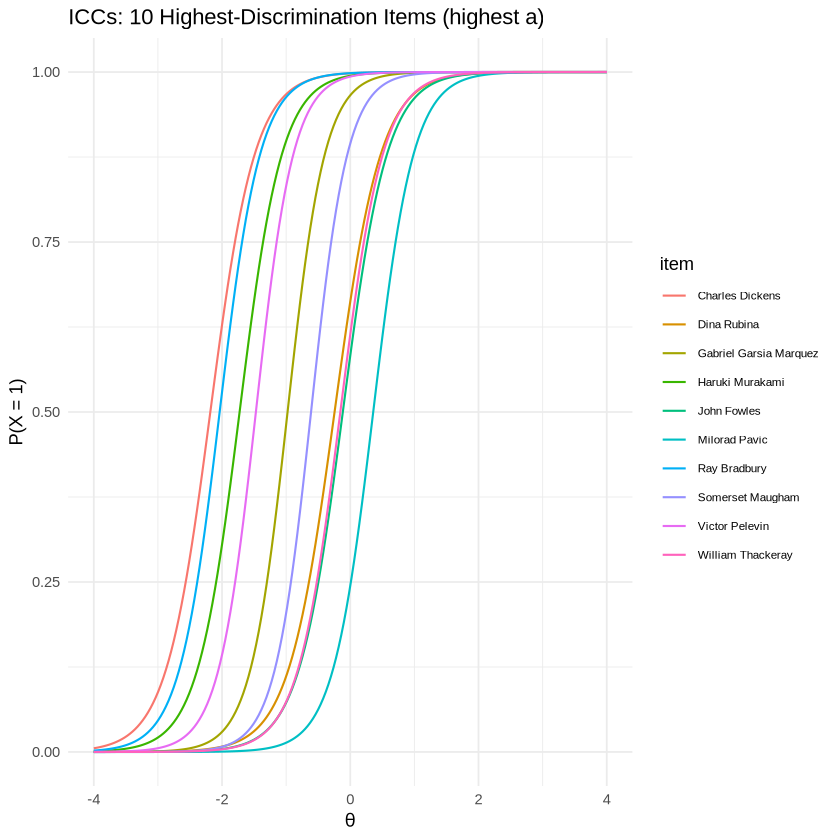

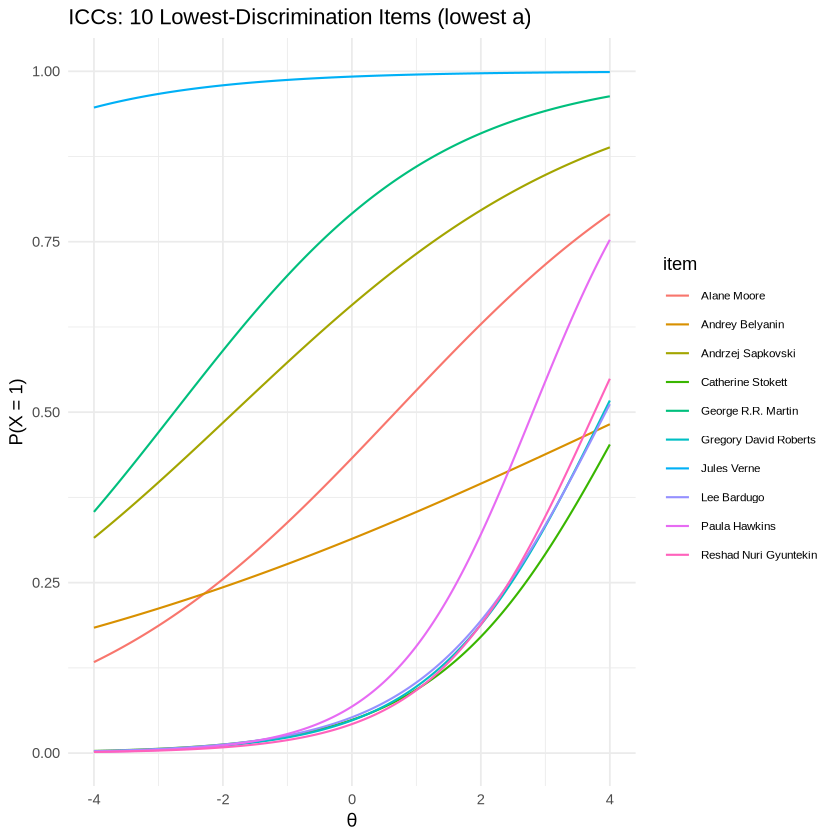

In [11]:
sorted_b <- params_df[order(params_df$irt06_2pl_b), ]
sorted_a <- params_df[order(params_df$irt06_2pl_a), ]

easiest_10  <- sorted_b$matrix_item_id[1:10]
hardest_10  <- sorted_b$matrix_item_id[(nrow(sorted_b) - 9):nrow(sorted_b)]
highest_a10 <- sorted_a$matrix_item_id[(nrow(sorted_a) - 9):nrow(sorted_a)]
lowest_a10  <- sorted_a$matrix_item_id[1:10]

theta_grid <- matrix(seq(-4, 4, length.out = 200), ncol = 1)

id_to_label <- setNames(item_key$item_label, item_key$matrix_item_id)

plot_icc_subset <- function(mod, item_ids, title) {
  item_nums <- which(colnames(author_mat) %in% item_ids)
  probs_list <- list()
  for (i in item_nums) {
    item_code <- colnames(author_mat)[i]
    label <- id_to_label[item_code]
    p <- probtrace(extract.item(mod, i), theta_grid)[, 2]
    probs_list[[label]] <- p
  }
  plot_df <- data.frame(
    theta = rep(theta_grid[, 1], length(probs_list)),
    prob  = unlist(probs_list),
    item  = rep(names(probs_list), each = nrow(theta_grid))
  )
  ggplot(plot_df, aes(x = theta, y = prob, color = item)) +
    geom_line(linewidth = 0.6) +
    labs(title = title, x = expression(theta), y = "P(X = 1)") +
    theme_minimal() +
    theme(legend.position = "right",
          legend.text = element_text(size = 7))
}

print(plot_icc_subset(mod_2pl, easiest_10,
                      "ICCs: 10 Easiest Items (lowest b)"))
print(plot_icc_subset(mod_2pl, hardest_10,
                      "ICCs: 10 Hardest Items (highest b)"))
print(plot_icc_subset(mod_2pl, highest_a10,
                      "ICCs: 10 Highest-Discrimination Items (highest a)"))
print(plot_icc_subset(mod_2pl, lowest_a10,
                      "ICCs: 10 Lowest-Discrimination Items (lowest a)"))

Peak information: 50.33 at theta = -0.14
Information at theta = -2: 23.43
Information at theta =  0: 49.88
Information at theta = +2: 10.31


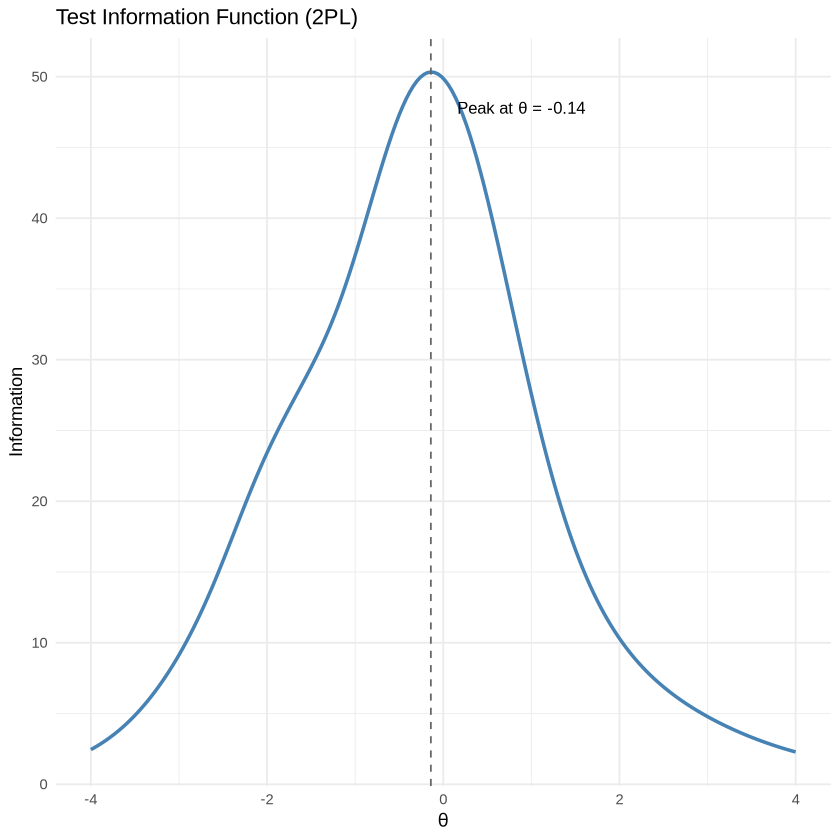

In [12]:
theta_seq  <- seq(-4, 4, length.out = 200)
info_vals  <- testinfo(mod_2pl, matrix(theta_seq, ncol = 1))

tif_df <- data.frame(theta = theta_seq, information = info_vals)

peak_theta <- theta_seq[which.max(info_vals)]
peak_info  <- max(info_vals)

p_tif <- ggplot(tif_df, aes(x = theta, y = information)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_vline(xintercept = peak_theta, linetype = "dashed", color = "grey40") +
  annotate("text", x = peak_theta + 0.3, y = peak_info * 0.95,
           label = sprintf("Peak at \u03b8 = %.2f", peak_theta),
           hjust = 0, size = 3.5) +
  labs(title = "Test Information Function (2PL)",
       x = expression(theta), y = "Information") +
  theme_minimal()
print(p_tif)

cat(sprintf("Peak information: %.2f at theta = %.2f\n", peak_info, peak_theta))
cat(sprintf("Information at theta = -2: %.2f\n", testinfo(mod_2pl, matrix(-2, ncol = 1))))
cat(sprintf("Information at theta =  0: %.2f\n", testinfo(mod_2pl, matrix( 0, ncol = 1))))
cat(sprintf("Information at theta = +2: %.2f\n", testinfo(mod_2pl, matrix( 2, ncol = 1))))

SE at theta = -2: 0.207
SE at theta =  0: 0.142
SE at theta = +2: 0.312


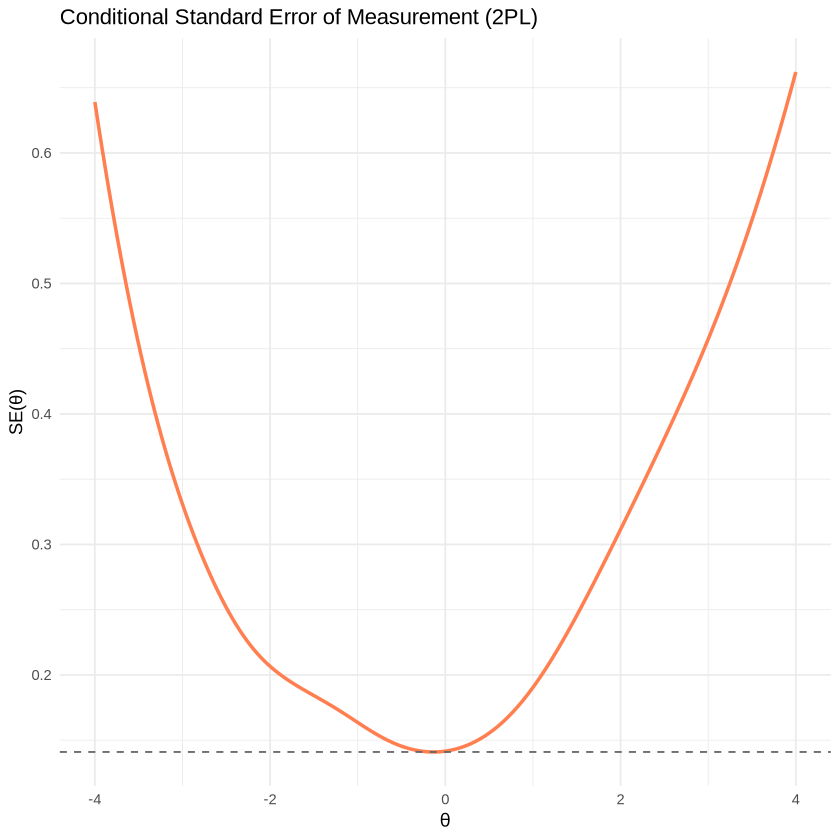

In [13]:
se_vals <- 1 / sqrt(info_vals)
se_df   <- data.frame(theta = theta_seq, se = se_vals)

p_se <- ggplot(se_df, aes(x = theta, y = se)) +
  geom_line(linewidth = 1, color = "coral") +
  geom_hline(yintercept = 1 / sqrt(peak_info), linetype = "dashed",
             color = "grey40") +
  labs(title = "Conditional Standard Error of Measurement (2PL)",
       x = expression(theta), y = "SE(\u03b8)") +
  theme_minimal()
print(p_se)

cat(sprintf("SE at theta = -2: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix(-2, ncol = 1)))))
cat(sprintf("SE at theta =  0: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix( 0, ncol = 1)))))
cat(sprintf("SE at theta = +2: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix( 2, ncol = 1)))))

── Theta (EAP) summary ──
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-2.188999 -0.690704 -0.043633 -0.001388  0.659341  3.354390 
  SD: 0.985

── Theta SE summary ──
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1402  0.1447  0.1547  0.1704  0.1803  0.4597 


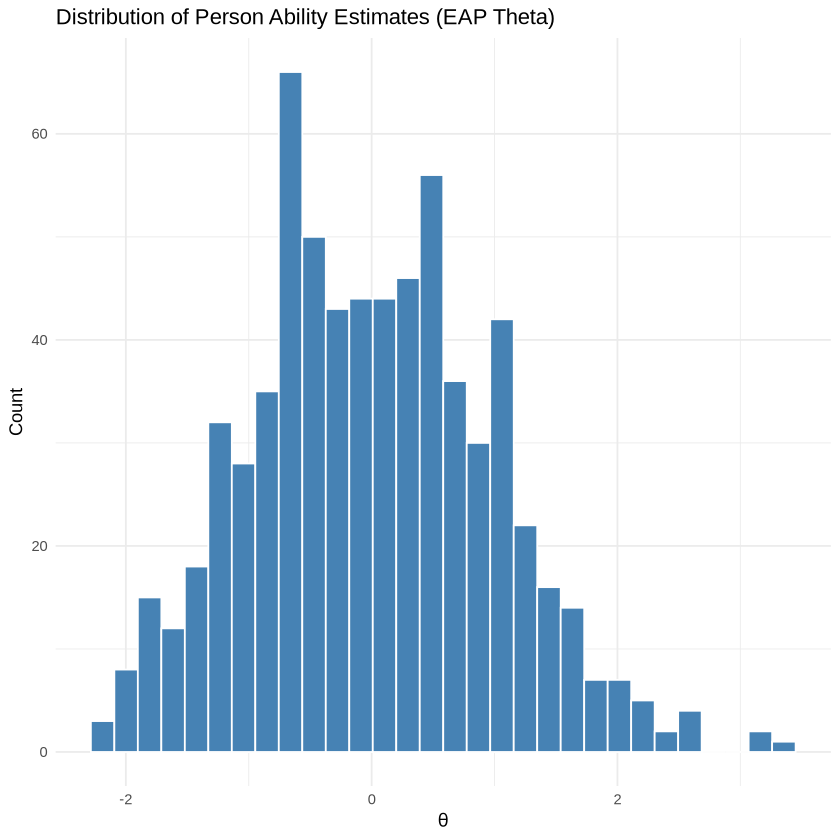

In [14]:
theta_mat <- fscores(mod_2pl, method = "EAP", full.scores.SE = TRUE)

theta_df <- data.frame(
  participant_id = author_df$participant_id,
  irt06_theta    = theta_mat[, 1],
  irt06_theta_se = theta_mat[, 2]
)

cat("\u2500\u2500 Theta (EAP) summary \u2500\u2500\n")
print(summary(theta_df$irt06_theta))
cat(sprintf("  SD: %.3f\n\n", sd(theta_df$irt06_theta)))

cat("\u2500\u2500 Theta SE summary \u2500\u2500\n")
print(summary(theta_df$irt06_theta_se))

p_theta <- ggplot(theta_df, aes(x = irt06_theta)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Person Ability Estimates (EAP Theta)",
       x = expression(theta), y = "Count") +
  theme_minimal()
print(p_theta)

In [15]:
item_out <- file.path(OUTPUT_DIR,
  "ART_pretest_(for Castano)_EN__irt_item_parameters.csv")
write.csv(item_key, item_out, row.names = FALSE)

theta_out <- file.path(OUTPUT_DIR,
  "ART_pretest_(for Castano)_EN__irt_theta_scores.csv")
write.csv(theta_df, theta_out, row.names = FALSE)

author_key_path <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv")
write.csv(item_key, author_key_path, row.names = FALSE)

irt06_cols <- grep("^irt06_|^flag_irt06_", names(item_key), value = TRUE)

cat("\u2500\u2500 Export summary \u2500\u2500\n\n")
cat(sprintf("Item parameters : %s\n", basename(item_out)))
cat(sprintf("  Rows: %d | Total columns: %d | New irt06 columns: %d\n",
            nrow(item_key), ncol(item_key), length(irt06_cols)))
cat(sprintf("  New columns: %s\n\n", paste(irt06_cols, collapse = ", ")))

cat(sprintf("Theta scores    : %s\n", basename(theta_out)))
cat(sprintf("  Rows: %d | Columns: %d\n\n", nrow(theta_df), ncol(theta_df)))

cat(sprintf("Updated item key: %s\n", basename(author_key_path)))
cat(sprintf("  (in %s)\n", basename(DATA_DIR)))

cat("\nDone. Re-run notebook to regenerate identical outputs.\n")

── Export summary ──

Item parameters : ART_pretest_(for Castano)_EN__irt_item_parameters.csv
  Rows: 98 | Total columns: 34 | New irt06 columns: 7
  New columns: irt06_2pl_a, irt06_2pl_b, flag_irt06_low_discrimination, flag_irt06_high_discrimination, flag_irt06_extreme_difficulty, irt06_keep_drop_review, irt06_rationale

Theta scores    : ART_pretest_(for Castano)_EN__irt_theta_scores.csv
  Rows: 688 | Columns: 3

Updated item key: ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv
  (in 03_dimensionality_inputs)

Done. Re-run notebook to regenerate identical outputs.


In [16]:
# Article package export (CSV tables + PNG/PDF figures for manuscript)

export_script <- file.path(PROJECT_ROOT, "scripts", "irt_analysis", "14_export_article_package.R")
source(export_script, local = FALSE)


Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06/table_model_comparison_1pl_2pl_3pl.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06/table_anova_1pl_vs_2pl.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06/table_anova_2pl_vs_3pl.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06/table_anova_model_comparisons.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06/table_2pl_item_parameters.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/resu

In [17]:
# --- Article package export (CSV tables + PNG/PDF figures + README) ---
# Writes to results/irt_item_calibration_article_package_2026-04-06/
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)
source(file.path(PROJECT_ROOT, "scripts", "article_exports", "18_export_irt_item_calibration_article_package.R"))


Fitting 1PL...
Fitting 2PL...
Fitting 3PL...


Warning message:
“Could not invert information matrix; model may not be (empirically) identified.”
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image


Article package written to:
  /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/irt_item_calibration_strict_fa_article_package_2026-04-06
